# 02. Linear regression and least squares

**Instructor:** Efraín Padilla — DLR IMF-ASP

**Estimated duration:** approximately 25 minutes.

Linear regression, the least-squares solution, and geometric visualization.

Run the cells from top to bottom. This notebook is one independent section of the workshop.

In [1]:
# --- Setup --- 

# Restart the kernel before running this cell if Matplotlib was already loaded.
import ipympl
# Enable interactive rotation and zooming for Matplotlib figures in VS Code.
get_ipython().run_line_magic("matplotlib", "ipympl")

# Import the numerical and plotting libraries used throughout the workshop.
import numpy as np
import matplotlib.pyplot as plt

# Choose plotting defaults that keep axes and mathematical curves readable.
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})

## 2. Linear regression and least squares

Suggested time: 25 minutes.

With optimization now established, linear regression gives us the first trainable model and a direct route from data to an analytical solution.

### Why linear regression?

Linear regression is one of the simplest ways to predict a continuous quantity from one or more input features. It is useful as a first model because its parameters are easy to interpret, its objective has a clear mathematical form, and it provides a baseline against which more flexible models can be compared.

In remote sensing, one sample might be a pixel, an image patch, or an observation from a time series. The input features could be spectral bands, band ratios, vegetation indices, texture measures, topographic variables, or temporal summaries. The target could be a continuous quantity such as leaf-area index, biomass, soil moisture, surface temperature, or a laboratory measurement.

A linear model assumes that the target can be approximated by a weighted sum of the input features. This assumption is often too simple for a final remote-sensing model, but it is valuable for understanding the data, checking preprocessing, and establishing a transparent baseline. Spatial context and nonlinear interactions are not learned automatically; they must be added explicitly or handled by a more expressive model.



### 2.1 A synthetic regression problem

We first use one input feature so that the relationship can be plotted directly. The data will contain an underlying linear trend plus noise, which represents variability not explained by the feature.

The first visualization should show the observations, the trend we want to estimate, and the difference between a prediction and its observed target.



### 2.2 Mathematical formulation

Let the training dataset be

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{N},\qquad x_i\in\mathbb{R}^{d},\quad y_i\in\mathbb{R}.
$$

Here, $N$ is the number of observations, $d$ is the number of features, $x_i$ is the feature vector for observation $i$, and $y_i$ is its measured target. The linear model predicts

$$
\hat{y}_i=w^Tx_i+b,
$$

where $w\in\mathbb{R}^{d}$ contains the feature weights and $b$ is the intercept or bias. The residual for observation $i$ is the prediction error

$$
e_i=\hat{y}_i-y_i.
$$

Least squares chooses $w$ and $b$ so that the sum of squared residuals is as small as possible. We use one half in the definition because it simplifies derivatives later:

$$
\mathcal{L}(w,b)=\frac{1}{2N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2.
$$

The square makes positive and negative errors contribute equally and penalizes large errors more strongly. The factor $1/N$ turns the sum into an average, so the loss is not directly determined by the number of observations.



### 2.3 Matrix form and the least-squares solution

It is convenient to include the bias in an augmented feature vector:

$$
\tilde{x}_i=\begin{bmatrix}1\\x_i\end{bmatrix},\qquad \theta=\begin{bmatrix}b\\w\end{bmatrix}.
$$

With the augmented design matrix $\tilde{X}$ and target vector $y$, all predictions can be written as $\hat{y}=\tilde{X}\theta$. The objective becomes

$$
\mathcal{L}(\theta)=\frac{1}{2N}\|\tilde{X}\theta-y\|_2^2.
$$

The key step is to set the gradient with respect to the parameters to zero. This gives the normal equations:

$$
\nabla_\theta\mathcal{L}(\theta)=\frac{1}{N}\tilde{X}^T(\tilde{X}\theta-y)=0\quad\Longrightarrow\quad\tilde{X}^T\tilde{X}\theta=\tilde{X}^Ty.
$$

The equation has a useful geometric interpretation. The residual vector $e=\tilde{X}\theta-y$ must be orthogonal to every column of $\tilde{X}$. If it had a component in one of those column directions, changing the corresponding parameter could reduce the squared error. The transpose $\tilde{X}^T$ collects these residual--feature correlations, so the gradient is zero exactly when all of them vanish.

Full column rank adds the condition needed to solve these equations uniquely. It makes the columns of $\tilde{X}$ linearly independent, so $\tilde{X}^T\tilde{X}$ is invertible. Because the least-squares loss is a convex quadratic, this unique stationary point is the global minimum:

$$
\theta^\star=(\tilde{X}^T\tilde{X})^{-1}\tilde{X}^Ty.
$$

Thus, setting the gradient to zero gives the normal equations; full column rank lets us turn those equations into a unique closed-form parameter vector. If the matrix is rank-deficient, the normal equations still describe least-squares minimizers, but the inverse does not exist and different parameter vectors may produce the same predictions.

In practical code, a least-squares solver is preferred to explicitly computing the inverse. The closed-form solution is useful here because it gives us a reference solution that we can later compare with gradient descent.

> **Workshop focus.** The essential ideas are the model, the residuals, and the loss. The normal-equation derivation is included as a reference; if time is limited, it can be summarized briefly before moving to gradient descent, which is the more direct bridge to neural-network training.



### 2.4 Optional reference: deriving the least-squares solution step by step

> This subsection is provided for later consultation. It is not necessary to cover every step during the live workshop.



#### Step 1: include the intercept in the parameter vector

The model $\hat{y}_i=w^Tx_i+b$ has a special parameter, $b$, that is not multiplied by an input feature. We can treat the intercept like any other weight by adding a constant feature equal to one:

$$
\tilde{x}_i=\begin{bmatrix}1\\x_i\end{bmatrix},\qquad \theta=\begin{bmatrix}b\\w\end{bmatrix}.
$$

The prediction is now $\hat{y}_i=\tilde{x}_i^T\theta$. If the original input has $d$ features, then $\tilde{x}_i$ has $d+1$ entries.



#### Step 2: stack all observations into a design matrix

Place one augmented input vector in each row of the design matrix:

$$
\tilde{X}=\begin{bmatrix}
1 & x_1^T\\
1 & x_2^T\\
\vdots & \vdots\\
1 & x_N^T
\end{bmatrix}\in\mathbb{R}^{N\times(d+1)}.
$$

The target vector is $y=[y_1,\ldots,y_N]^T$. Multiplying the design matrix by $\theta$ produces all predictions at once:

$$
\hat{y}=\tilde{X}\theta.
$$



#### Step 3: write the loss using a vector norm

The residual vector is $e=\hat{y}-y=\tilde{X}\theta-y$. Its squared Euclidean norm is the sum of the squared residuals, so

$$
\mathcal{L}(\theta)=\frac{1}{2N}\|\tilde{X}\theta-y\|_2^2.
$$

Using $\|a\|_2^2=a^Ta$, the same objective can be written as

$$
\mathcal{L}(\theta)=\frac{1}{2N}(\tilde{X}\theta-y)^T(\tilde{X}\theta-y).
$$



#### Step 4: expand the quadratic expression

Expanding the product gives

$$
\mathcal{L}(\theta)=\frac{1}{2N}\left(\theta^T\tilde{X}^T\tilde{X}\theta-2y^T\tilde{X}\theta+y^Ty\right).
$$

The final term, $y^Ty$, does not depend on $\theta$. It affects the value of the loss but not the location of its minimum.



#### Step 5: differentiate with respect to the parameters

The gradient of the loss is

$$
\nabla_\theta\mathcal{L}(\theta)=\frac{1}{N}\tilde{X}^T(\tilde{X}\theta-y).
$$

The transpose $\tilde{X}^T$ maps the residuals from observation space back to parameter space. It combines the residuals according to the feature values.



#### Step 6: impose the stationary-point condition

At a differentiable interior minimum, the gradient is zero:

$$
\frac{1}{N}\tilde{X}^T(\tilde{X}\theta-y)=0.
$$

Multiplying by $N$ and rearranging gives the normal equations:

$$
\tilde{X}^T\tilde{X}\theta=\tilde{X}^Ty.
$$



#### Step 7: understand the full-column-rank condition

The design matrix $\tilde{X}$ has full column rank when its $d+1$ columns are linearly independent:

$$
\operatorname{rank}(\tilde{X})=d+1.
$$

This requires at least $N\ge d+1$ observations and no exact linear dependence among the columns. Under this condition, $\tilde{X}^T\tilde{X}$ is invertible. To see why, take any nonzero vector $v$:

$$
v^T\tilde{X}^T\tilde{X}v=\|\tilde{X}v\|_2^2>0.
$$

The strict inequality follows because full column rank implies $\tilde{X}v\ne0$ whenever $v\ne0$. Therefore $\tilde{X}^T\tilde{X}$ is positive definite and has an inverse.



#### Step 8: solve the normal equations

Multiplying the normal equations by $(\tilde{X}^T\tilde{X})^{-1}$ gives

$$
\theta^\star=(\tilde{X}^T\tilde{X})^{-1}\tilde{X}^Ty.
$$

This is the closed-form least-squares solution. In numerical work, use a QR- or SVD-based least-squares solver instead of explicitly forming the inverse. This is especially important in remote sensing, where spectral bands and derived indices can be highly correlated.



#### A small hand-worked example

For one feature and three observations, let $x=[1,2,3]^T$ and $y=[2,3,5]^T$. Including the intercept gives

$$
\tilde{X}=\begin{bmatrix}1&1\\1&2\\1&3\end{bmatrix},\qquad \tilde{X}^T\tilde{X}=\begin{bmatrix}3&6\\6&14\end{bmatrix},\qquad \tilde{X}^Ty=\begin{bmatrix}10\\23\end{bmatrix}.
$$

The determinant of $\tilde{X}^T\tilde{X}$ is $3\cdot14-6\cdot6=6$, so the matrix is invertible. Solving the normal equations gives $\theta^\star=[1/3,3/2]^T$. Thus the fitted model is $\hat{y}=1/3+(3/2)x$.

If two columns were duplicates or exact linear combinations, the determinant would be zero and the inverse would not exist. A least-squares solver or pseudoinverse can still provide a solution, but the parameters may no longer be unique.



### 2.5 Visual interpretation

The fitted line or plane is the set of predictions produced by the optimal parameters. We will first use one feature, where the model is a line, and then use two features, where the model becomes a plane. In both cases, the plot will make the parameters visible: the bias controls the offset and each weight controls the contribution of its corresponding feature.

#### 2.5.1 One input feature: a fitted line

For one feature, $\hat{y}=b+wx$. Here, $w$ is the weight of the input feature; in one dimension it is the slope of the line. The parameter $b$ is the bias or intercept, so it determines the predicted value when $x=0$.

The data-generating process is

$$
x_i\sim\mathcal{U}(0,10),\qquad y_i=1.5+2.2x_i+\varepsilon_i,\qquad \varepsilon_i\sim\mathcal{N}(0,2^2).
$$

The feature $x$ is sampled from a uniform distribution between 0 and 10. Its theoretical mean is $5$ and its theoretical standard deviation is $(10-0)/\sqrt{12}\approx2.89$. The noise $\varepsilon$ is sampled from a normal distribution with mean $0$ and standard deviation $2$; therefore, `rng.normal(0, 2.0, n_samples)` uses $0$ as the mean and $2.0$ as the standard deviation.

Before noise is added, the true line has bias $b=1.5$ and weight $w=2.2$. The noise moves each observation above or below this line. Consequently, the sample mean and standard deviation will not be exactly equal to their theoretical values, and the fitted parameters will be close to, but not exactly equal to, $1.5$ and $2.2$. The random seed makes this particular dataset reproducible.

#### Visualization guide: one-feature linear regression

This plot compares noisy observations with the fitted least-squares line. The horizontal axis is the input feature, the vertical axis is the continuous target, and the line summarizes the relationship learned by the model.

Look at the residuals—the vertical differences between observations and predictions—and at the fitted weight and bias. You can change `n_samples`, the noise standard deviation in the data-generation expression, and the underlying slope or intercept.

**Open question:** How do the fitted weight and bias change when the noise becomes larger or when the sample size becomes smaller?

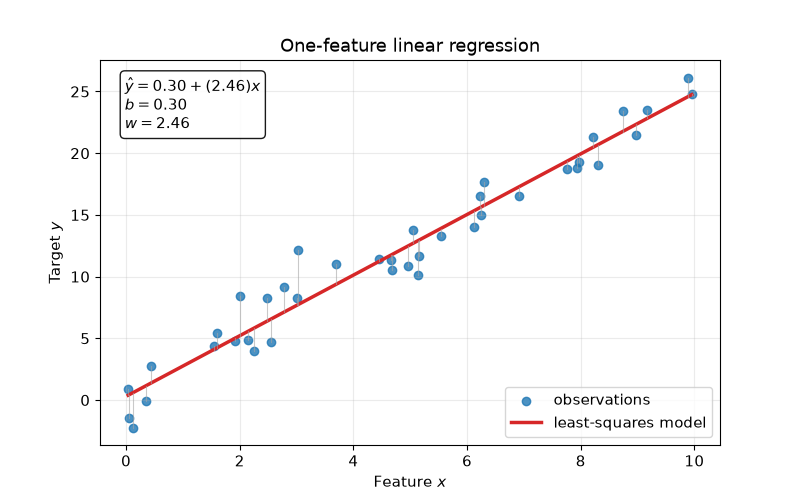

In [2]:
rng = np.random.default_rng(7)
n_samples = 40
x = rng.uniform(0, 10, n_samples)
y = 1.5 + 2.2 * x + rng.normal(0, 2.0, n_samples)

# The augmented design matrix has one row per observation: [1, x_i].
# The column of ones is what allows the model to learn an intercept (bias).
X = np.c_[np.ones(n_samples), x]
# theta = [b, w]^T, so the vectorized predictions are y_hat = X @ theta.
# In other words, each row computes b + w * x_i.
theta, *_ = np.linalg.lstsq(X, y, rcond=None)
# least_squares minimizes ||X @ theta - y||_2^2 and returns the best parameters.
b, w = theta

x_plot = np.linspace(x.min(), x.max(), 200)
y_plot = b + w * x_plot
y_pred = b + w * x
equation = fr"$\hat{{y}} = {b:.2f} + ({w:.2f})x$"
parameters = f"$b = {b:.2f}$\n$w = {w:.2f}$"

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="tab:blue", alpha=0.8, label="observations")
ax.plot(x_plot, y_plot, color="tab:red", linewidth=2.5, label="least-squares model")
for xi, yi, ypi in zip(x, y, y_pred):
    ax.plot([xi, xi], [yi, ypi], color="0.65", linewidth=0.8, alpha=0.6)

ax.text(0.04, 0.96, equation + "\n" + parameters, transform=ax.transAxes,
        va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
ax.set_title("One-feature linear regression")
ax.set_xlabel("Feature $x$")
ax.set_ylabel("Target $y$")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

#### 2.5.2 Two input features: a fitted plane

With two features, $\hat{y}=b+w_1x_1+w_2x_2$. The same least-squares procedure now fits a plane in the three-dimensional space $(x_1,x_2,y)$. The plane is the two-feature analogue of the line above.

The data are generated as

$$
x_{1i}\sim\mathcal{U}(-3,3),\qquad x_{2i}\sim\mathcal{U}(-2,2),
$$
$$
y_i=4.0+1.4x_{1i}-2.1x_{2i}+\varepsilon_i,\qquad \varepsilon_i\sim\mathcal{N}(0,1.2^2).
$$

Both features have theoretical mean $0$. Their theoretical standard deviations are $6/\sqrt{12}\approx1.73$ for $x_1$ and $4/\sqrt{12}\approx1.15$ for $x_2$. The noise has mean $0$ and standard deviation $1.2$. Thus, the true plane has bias $b=4.0$, weights $w_1=1.4$ and $w_2=-2.1$, while the fitted values vary slightly because of the finite sample and the added noise.

> The setup cell enables Matplotlib's `ipympl` backend. In VS Code, restart the kernel, run the setup cell first, and then run this visualization cell. Interact with the 3D figure by dragging to rotate and using the scroll wheel to zoom.

#### Visualization guide: two-feature regression and the fitted plane

This visualization extends the previous line to two input features. The points represent observations in $(x_1,x_2,y)$ space, while the plane represents the predictions of the fitted linear model.

Rotate the 3D figure to inspect the plane from different directions. You can change `n_samples`, the feature ranges, the noise level, and the coefficients used to generate the dummy targets.

**Open question:** Which views make it easiest to judge the quality of the fit, and what would happen if the two features became strongly correlated?

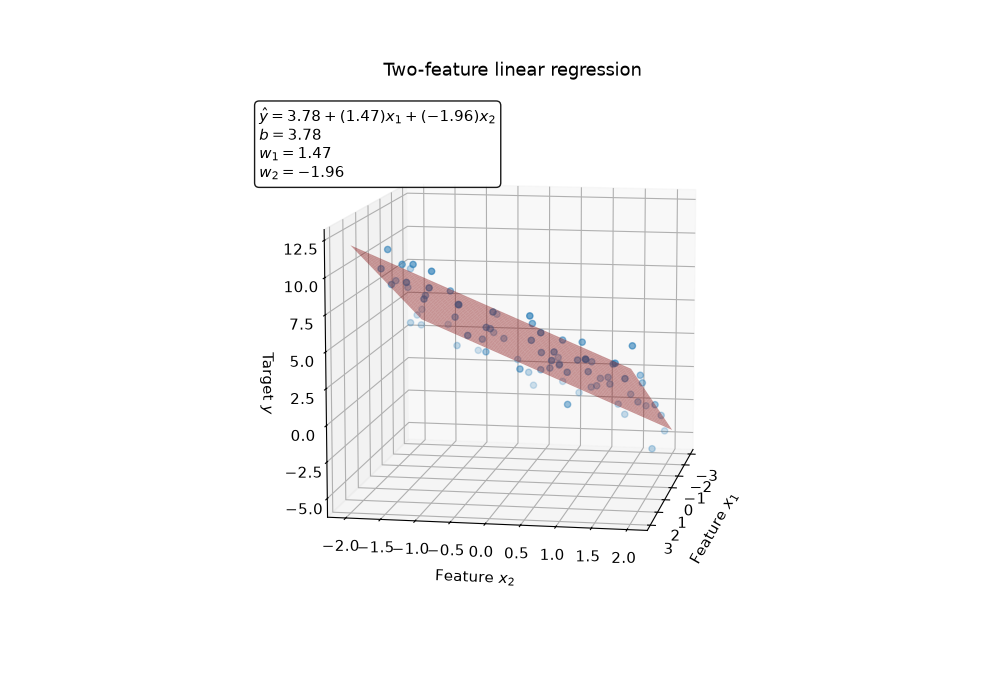

In [3]:
rng = np.random.default_rng(21)
n_samples = 80
x1 = rng.uniform(-3, 3, n_samples)
x2 = rng.uniform(-2, 2, n_samples)
y = 4.0 + 1.4 * x1 - 2.1 * x2 + rng.normal(0, 1.2, n_samples)

# Each row of the augmented design matrix is [1, x_1i, x_2i].
# The first column represents the bias; the other columns represent the two features.
X = np.c_[np.ones(n_samples), x1, x2]
# theta = [b, w_1, w_2]^T, hence y_hat = X @ theta.
# Every row evaluates b + w_1*x_1i + w_2*x_2i.
theta, *_ = np.linalg.lstsq(X, y, rcond=None)
# This minimizes the total squared residual ||X @ theta - y||_2^2.
b, w1, w2 = theta

x1_grid = np.linspace(x1.min(), x1.max(), 30)
x2_grid = np.linspace(x2.min(), x2.max(), 30)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Y_plane = b + w1 * X1 + w2 * X2
equation = fr"$\hat{{y}} = {b:.2f} + ({w1:.2f})x_1 + ({w2:.2f})x_2$"
parameters = f"$b = {b:.2f}$\n$w_1 = {w1:.2f}$\n$w_2 = {w2:.2f}$"

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x1, x2, y, color="tab:blue", alpha=0.8, label="observations")
ax.plot_surface(X1, X2, Y_plane, color="tab:red", alpha=0.45,
                edgecolor="none", label="least-squares plane")

ax.text2D(0.03, 0.96, equation + "\n" + parameters, transform=ax.transAxes,
          va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
ax.set_title("Two-feature linear regression")
ax.set_xlabel("Feature $x_1$", labelpad=8)
ax.set_ylabel("Feature $x_2$", labelpad=8)
ax.set_zlabel("Target $y$", labelpad=8)
ax.set_box_aspect((1.2, 1.0, 0.9))
ax.view_init(elev=10, azim=10)
plt.show()